# Function 1

This function is described by 2 input features, each of which are nomalised to lie within the range 0 and 1. The optimisation goal is to maximise the output value. The function describes the radiation from contamination sources in a two-dimensional area. Proximity to a source yields a non-zero reading. The initial data set consists of 10 data points.

## Week 1 - Initial exploration

In [1]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_gp_surfaces
from bbo.utils import construct_meshgrid, get_farthest_point

seed_input = "function 1"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [2]:
X, y = get_current_weeks_points(function_id=1, week=1)

print(f"Mean = {y.mean()}")
print(f"Standard deviation = {y.std()}")

print(f"Minimum = {y.min()}")
quantiles = [0.25, 0.5, 0.75]
for quantile in quantiles:
    print(f"{quantile * 100}% quantile = {np.quantile(y, quantile)}")
print(f"Maximum = {y.max()}")

Mean = -0.00036060626443627054
Standard deviation = 0.0010818187933090686
Minimum = -0.0036060626443634764
25.0% quantile = -1.566819952674063e-91
50.0% quantile = 6.79372375723414e-80
75.0% quantile = 7.903833193127448e-47
Maximum = 7.710875114502849e-16


Initial exploratory data analysis reveals very small output values. The minimum output value is negative, and there are quite a few points with negative values. The absolute value of the minimum is approximately 13 orders of magnitude larger than the maximum. The minimum dominates the mean, and the median is a more useful measure of the average.

Given that the output values are several orders of magnitude apart, it may be worth considering a logarithmic rather than linear scale. However, a decision would need to be made on what to do with the negative outputs. Given that they form a significant proportion of the known data points, we would lose quite a lot of potentially useful information by dropping them.

As there are a relatively small number of observed data points and given the limited number of queries we can submit, we apply Bayesian Optimisation. We fit a Gaussian Process surrogate model to the data, allowing us to model the underlying function and its associated uncertainty. A Radial Basis Function (RBF) kernel is chosen initially, and it is assumed at this stage that both features are of equal importance and therefore the length scales are fixed at 0.1.

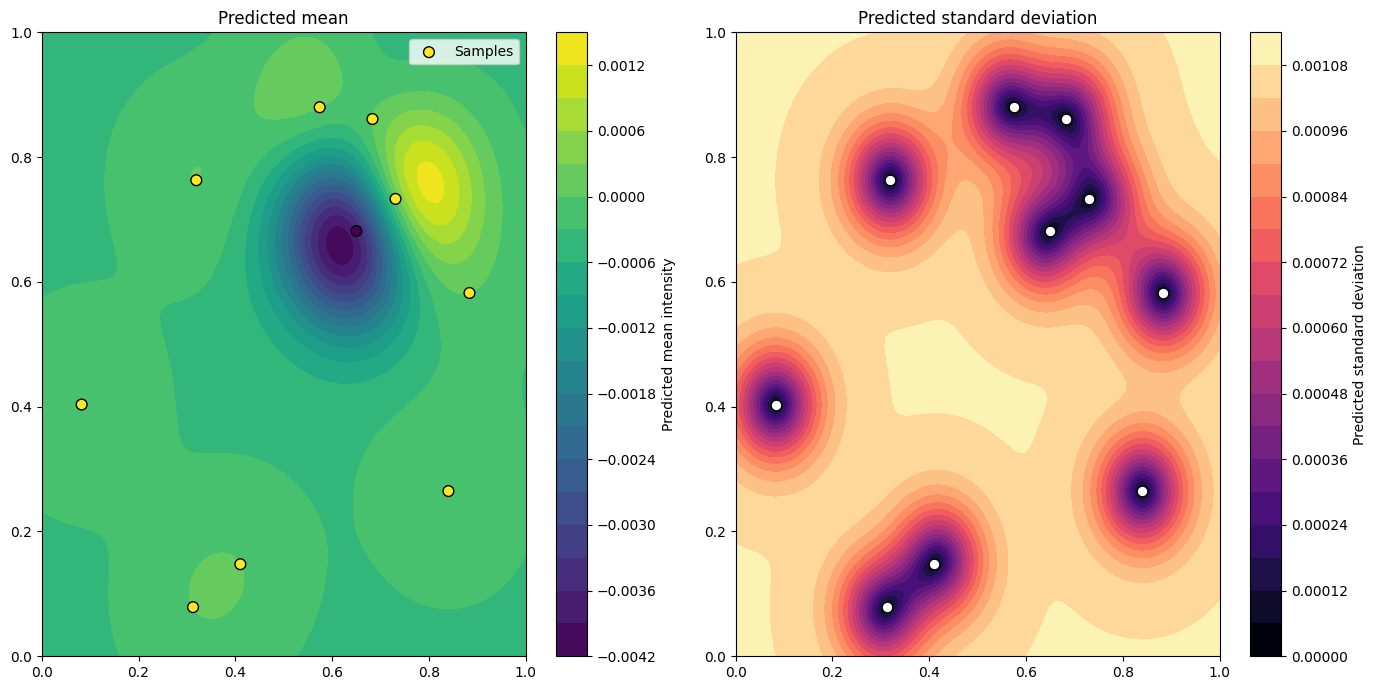

In [3]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.1, 0.1], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True
)
model.fit(X, y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

From the contour plot, there appears to be a promising region at around (0.8, 0.8). However, the current maximum value is so small that it is unsure whether this is even an indication of a peak. It could be the case that all observed data points lie in the noise. Therefore, it may be a good idea to query the point of highest uncertainty. This can be done by ignoring the mean and performing a grid search to find the point with the highest standard deviation.

In [4]:
# Use standard deviation as acquisition function for pure exploration
max_idx = np.unravel_index(np.argmax(Y_std), Y_std.shape)
x_next = np.array([X0[max_idx], X1[max_idx]])
print(f"Proposed point using pure exploration acquisition function = {x_next}")

Proposed point using pure exploration acquisition function = [0. 1.]


This point is found to lie in one of the corners, and little information would be gained here. We could move a bit closer to the centre and query the point (0.05, 0.95). If we assume that all observed data points lie in the noise, it may be worth simply ignoring the Gaussian Process surrogate model for now and finding a point that lies farthest from any observed data points and corners.

In [5]:
# Find farthest point on grid from any corners or samples
x_next = get_farthest_point(X, n_dimensions, grd_res)
print(f"Farthest point on grid from any corners or samples = {x_next}")

Farthest point on grid from any corners or samples = [0.421 0.464]


## Week 2 - A new minimum!

In [6]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_gp_surfaces
from bbo.utils import construct_meshgrid, get_farthest_point

seed_input = "function 1"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [7]:
X, y = get_current_weeks_points(function_id=1, week=2)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.421 0.464] yields -0.007205629781049314


The result from last week's query is a new minimum! However, we are still in the exploratory stage and with this result we can eliminate a significantly large area with the Gaussian Process surrogate model:

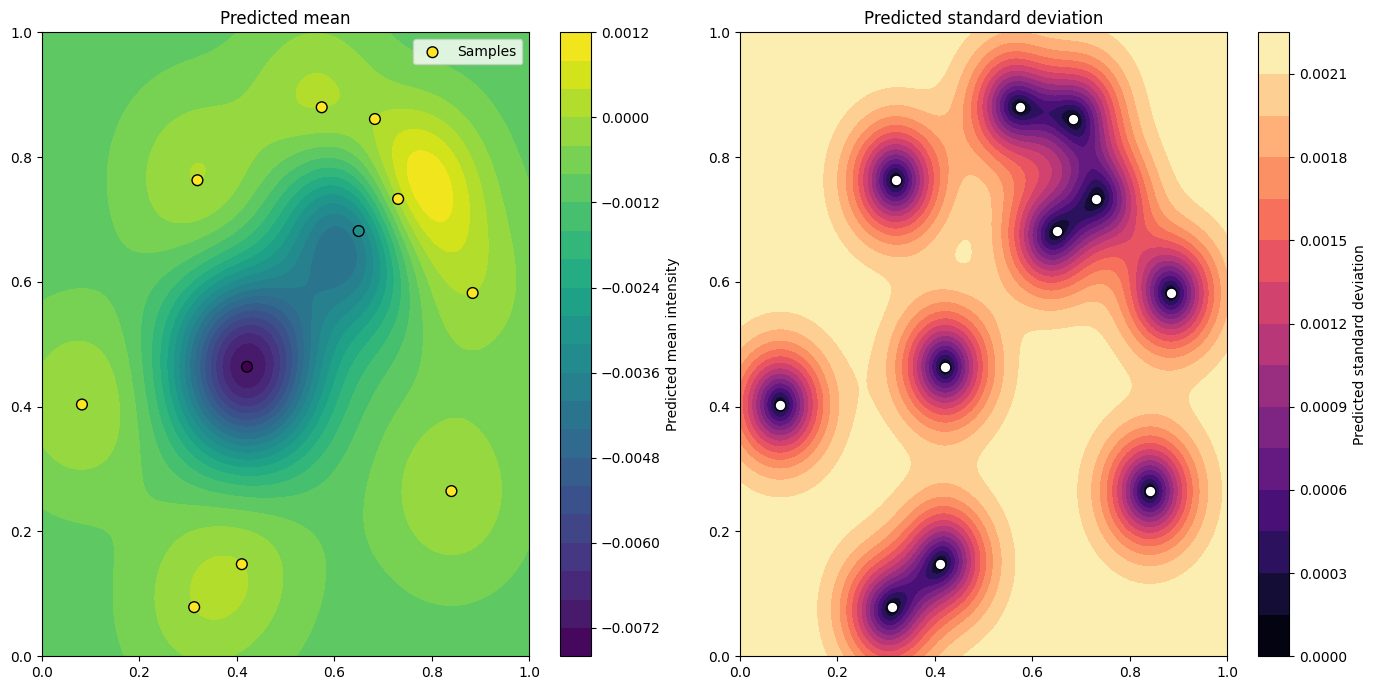

In [8]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.1, 0.1], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True
)
model.fit(X, y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

The region around (0.8, 0.8) looks even more promising. However, the predicted mean intensity here is still rather low. It could be that the output values are small, and therefore my previous assumption that the observed data points are just noise is false. Having said that, we have the time to query other regions of space before testing this region.

In [9]:
# Use standard deviation as acquisition function for pure exploration
max_idx = np.unravel_index(np.argmax(Y_std), Y_std.shape)
x_next = np.array([X0[max_idx], X1[max_idx]])
print(f"Proposed point using pure exploration acquisition function = {x_next}")

Proposed point using pure exploration acquisition function = [0. 1.]


Again, the point where the model is least certain lies in the corner. Rather than query this point, we can find the point that lies farthest from the corners or observed data points:

In [10]:
# Find farthest point on grid from any corners or samples
x_next = get_farthest_point(X, n_dimensions, grd_res)
print(f"Farthest point on grid from any corners or samples = {x_next}")

Farthest point on grid from any corners or samples = [0.682 0.   ]


This lies on a boundary rather than in a corner. Of the two candidates we have identified, it is the one likely to yield more information.

## Week 3 - Exploring a promising region

In [11]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo import acquisition
from bbo.data import get_current_weeks_points
from bbo.plotting import plot_2d_gp_surfaces
from bbo.utils import construct_meshgrid, get_farthest_point

seed_input = "function 1"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [12]:
X, y = get_current_weeks_points(function_id=1, week=3)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.682 0.   ] yields 5.596684327963654e-172


Last week's query yields a positive output, albeit many orders of magntiude smaller than the current best observed point.

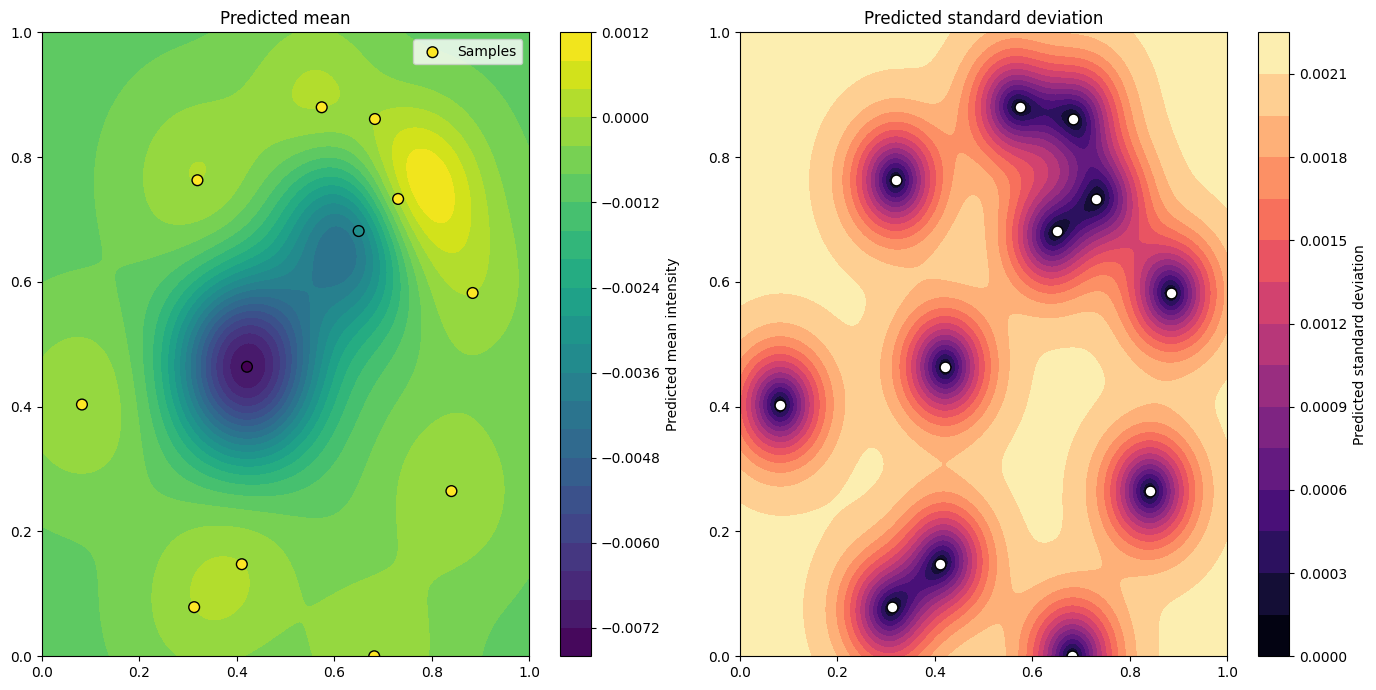

In [13]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.1, 0.1], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True
)
model.fit(X, y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

Again, the model identifies an area around (0.8, 0.8) as promising. As we still have some time, and there has been no significant breakthrough, we can take a look at some other candidates before we explore this region.

In [14]:
# Use standard deviation as acquisition function for pure exploration
max_idx = np.unravel_index(np.argmax(Y_std), Y_std.shape)
x_next = np.array([X0[max_idx], X1[max_idx]])
print(f"Proposed point using pure exploration acquisition function = {x_next}")

# Find farthest point on grid from any corners or samples
x_next = get_farthest_point(X, n_dimensions, grd_res)
print(f"Farthest point on grid from any corners or samples = {x_next}")

Proposed point using pure exploration acquisition function = [0. 1.]
Farthest point on grid from any corners or samples = [0.    0.696]


Using the same aquisition functions as we have in previous weeks, we get candidates to query that are close to the boundaries. The algorithm to find the farthest point from any corners or observed data points yields a point that is the mirror image of last week's query.

In [15]:
# Use Upper Confidence Bound (UCB) acquisition function with k = 1.96 (95% confidence interval)
max_idx = np.unravel_index(np.argmax(acquisition.ucb(Y_mean, Y_std, k=1.96)), Y_mean.shape)
x_next = np.array([X0[max_idx], X1[max_idx]])
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = {x_next}")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.856 0.772]


The Upper Confidence Bound (UCB) acquisition function with exploration parameter k = 1.96, which corresponds to 95% confidence interval, suggests querying a point that lies close to the promising region identified by the Gaussian Process surrogate model. It also lies sufficiently far away from any boundaries, so this is the next point that should be queried.

## Week 4 - Attempting to fit linear regression models

In [16]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF

from bbo import acquisition
from bbo.data import get_current_weeks_points
from bbo.linear_regression import get_lr_models, kfoldcv, loocv
from bbo.plotting import plot_2d_gp_surfaces, plot_correlation_matrix
from bbo.stats import get_baseline_rmse, get_baseline_mse
from bbo.utils import construct_meshgrid, grid_search

seed_input = "function 1"  # input string to create random seed
n_dimensions = 2  # number of features
grd_res = 1001  # axis resolution

In [17]:
X, y = get_current_weeks_points(function_id=1, week=4)

print(f"Last week's query {X[-1]} yields {y[-1]}")

Last week's query [0.856 0.772] yields -9.061632524598372e-51


The promising region may not be that promising after all as last week's query yields a negative output. This could be because the RBF kernel is too smooth and a Matern kernel may be better. For now, however, I do not feel there is enough information to make that decision, and therefore we should stick with the RBF kernel.

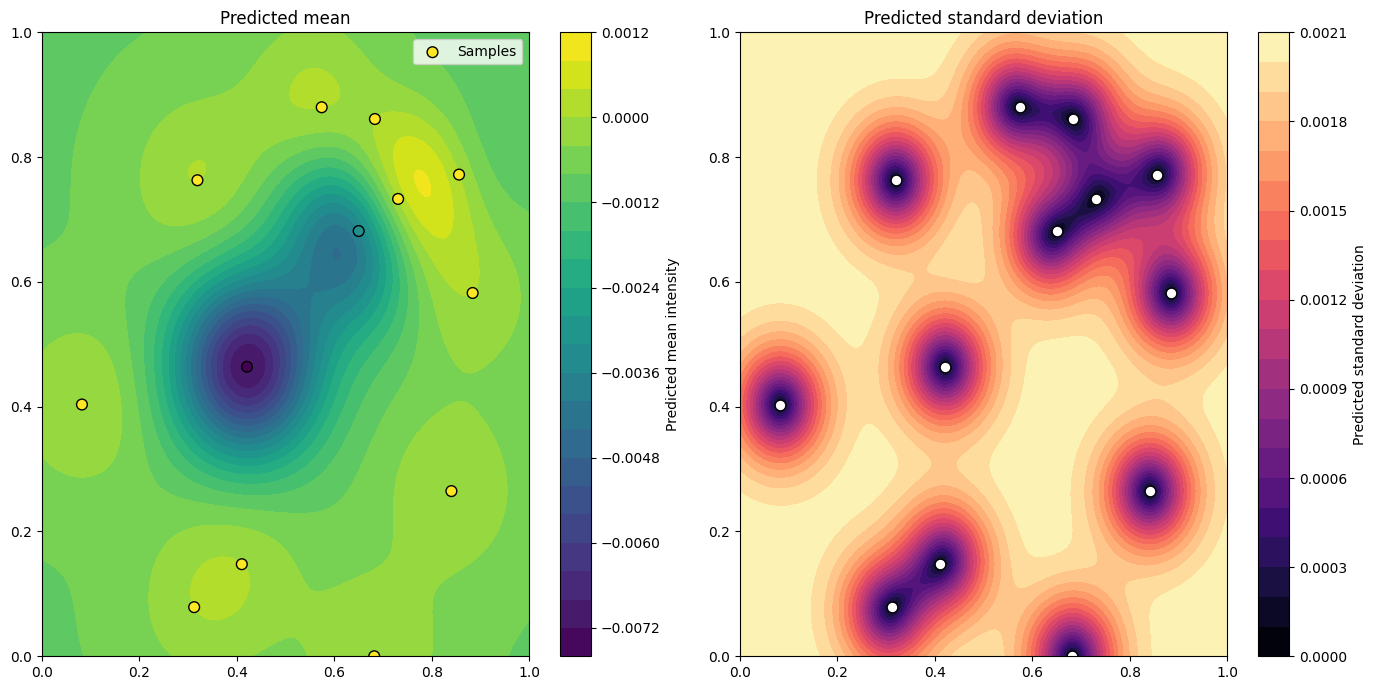

In [18]:
# Fit Gaussian Process surrogate model on known data
kernel = RBF(length_scale=[0.1, 0.1], length_scale_bounds='fixed')
model = GaussianProcessRegressor(
    kernel=kernel, n_restarts_optimizer=10, normalize_y=True
)
model.fit(X, y)

# Perform grid search to evaluate model output
X0, X1 = construct_meshgrid(n_dimensions=n_dimensions, grd_res=grd_res)
X_pred = np.column_stack([X0.ravel(), X1.ravel()])
y_mean, y_std = model.predict(X_pred, return_std=True)
Y_mean = y_mean.reshape(grd_res, grd_res)
Y_std = y_std.reshape(grd_res, grd_res)

# Plot predicted means and standard deviations
fig, axs = plot_2d_gp_surfaces(
    X0=X0, X1=X1, Y_mean=Y_mean, Y_std=Y_std, x_samples=X, y_samples=y
)

Although the promising area around (0.8, 0.8) has shrunk, it still looks promising.

In [19]:
# Use Upper Confidence Bound (UCB) acquisition function with k = 1.96 (95% confidence interval)
max_idx = np.unravel_index(np.argmax(acquisition.ucb(Y_mean, Y_std, k=1.96)), Y_mean.shape)
x_next = np.array([X0[max_idx], X1[max_idx]])
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = {x_next}")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.4   0.925]


However, the UCB acquisition function suggests a different region to explore next. This is probably because of the relatively high value of the exploration parameter `k`. I am still not convinced that the largest observed value corresponds to a peak. Coupled with my opinion that there are enough queries left to allow for further exploration, the point proposed by the UCB acquisition function holds promise.

Before we continue down this path, I would like to explore whether a linear regression model could describe the underlying data.

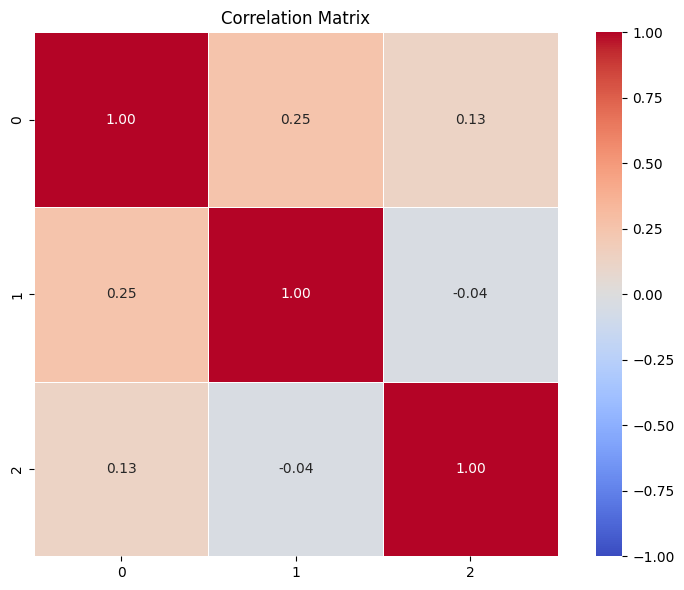

In [20]:
fig, ax = plot_correlation_matrix(X, y)

In [21]:
print(f"Baseline RMSE = {get_baseline_rmse(y)}")

cv_methods = {
    "Leave One Out Cross Validation": loocv(X, y),
    "5-Fold Cross Validation": kfoldcv(X, y, seed_input=seed_input, n_splits=5),
}
for method, scores in cv_methods.items():
    print(f"\n{method}")
    for name, stats in scores.items():
        print(f"{name} model: RMSE = {stats['RMSE']}, RMSE spread = {stats['RMSE spread']}, relative RMSE = {stats['relative RMSE']}")

Baseline RMSE = 0.002074256914460062

Leave One Out Cross Validation
linear model: RMSE = 0.002402876884556735, RMSE spread = 0.0016754334169124991, relative RMSE = 0.33347215407541536
quadratic model: RMSE = 0.0026536567059403907, RMSE spread = 0.0016145552207537325, relative RMSE = 0.3682754716207013
cubic model: RMSE = 0.003244353982608727, RMSE spread = 0.0022035640618444014, relative RMSE = 0.4502526609320086

5-Fold Cross Validation
linear model: RMSE = 0.002422954988315756, RMSE spread = 0.012819789905620166, relative RMSE = 0.33625860083567266
quadratic model: RMSE = 0.003354375007043472, RMSE spread = 0.010012485499752158, relative RMSE = 0.4655214199132272
cubic model: RMSE = 0.012383883669805236, RMSE spread = 0.03873715964638164, relative RMSE = 1.7186400142806835


There does not appear to be any clear correlation between any of the input features and the output, which would indicate that a linear fit would not be suitable.

We perform leave one out and 5-fold cross-validations, and compare the Root Mean Square Errors (RMSE). There are a couple of things to note. Firstly, none of the models within errors perform better than the baseline RMSE, which has been calculated using the mean as the predicted value for all observations. Secondly, the baseline RMSE is very large, because of the two very large negative values. We can mitigate this somewhat by using the Mean Square Error (MSE) instead:

In [22]:
print(f"Baseline MSE = {get_baseline_mse(y)}")

for method, scores in cv_methods.items():
    print(f"\n{method}")
    for name, stats in scores.items():
        print(f"{name} model: MSE = {stats['RMSE']}, MSE spread = {stats['RMSE spread']}")

Baseline MSE = 0.0014074392506454698

Leave One Out Cross Validation
linear model: MSE = 0.002402876884556735, MSE spread = 0.0016754334169124991
quadratic model: MSE = 0.0026536567059403907, MSE spread = 0.0016145552207537325
cubic model: MSE = 0.003244353982608727, MSE spread = 0.0022035640618444014

5-Fold Cross Validation
linear model: MSE = 0.002422954988315756, MSE spread = 0.012819789905620166
quadratic model: MSE = 0.003354375007043472, MSE spread = 0.010012485499752158
cubic model: MSE = 0.012383883669805236, MSE spread = 0.03873715964638164


While the baseline MSE is smaller than the baseline RMSE, none of the models appear to be more accurate within errors.

While it may be useful to revisit linear regression in the future, at the moment, we should stick with the Gaussian Process surrogate model. We can perform a grid search to identify the point that yields the highest value for the UCB acquisition function, as we have done above. We can then zoom in on this point and perform another search, effectively at a higher resolution. We can repeat this until the we reach a resolution in the order of 1e-6, which is equivalent to the maximum number of decimal places that can be given to the inputs when submitting queries.

This is overkill in many respects, as the differences in outputs at these scales are likely to be negligible, and we do not have enough queries to explore to this accuracy. However, it does not result in any harm if we were going to select this point anyway, and is a useful exercise for future.

Better regions that warrant investigation can be masked by simply selecting the best point. While this is mitigated by using finer grid coordinates, this becomes harder at higher dimensions.

In [23]:
x_next = grid_search(model, acq_func=acquisition.ucb, k=1.96, n_dimensions=2, grd_res=grd_res)
print(f"Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = {x_next}")

Proposed point using Upper Confidence Bound (k = 1.96) acquisition function = [0.39983909 0.92483909]
